# Tutorial 10: Spatial Anisotropy Analysis and Anisotropic BME Estimation

This tutorial demonstrates the complete anisotropy analysis workflow in `stamps`:

1. **Data loading and visualization** — US Total Ozone dataset (TOMS, 5 months)
2. **Visual screening** — 2-D covariance map and polar directional covariance
3. **Effect size** — automatic anisotropy parameter estimation
4. **Formal isotropy test** — spatial rotation bootstrap test
5. **Anisotropic WLS model fitting** — fitting a covariance model with (θ, r)
6. **Anisotropic BME estimation** — applying the anisotropic model in kriging / BME

**Dataset:** US Total Ozone (Dobson Units), months 6–10, from the STARBME example package.
Hard data are station measurements; soft data are Gaussian probability intervals from satellite
retrievals (mean ± standard deviation at each grid cell).

**Reference:**  
Christakos, G. & Vyas, V.M. (1998). A novel method for studying population exposure to
outdoor air pollutants. *Environment International*, 24(1–2), 141–158.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# stamps modules
import stamps
from stamps.stats.dependence.covariance.stcov import stcov
from stamps.stats.dependence.covariance.stcovfit import covmodelfit
from stamps.stats.dependence import (
    aniso2iso, iso2aniso,
    polarstcovmap,
    covariancemap,
    estimate_anisotropy_params,
    isotropy_test,
)
from stamps.general.coord2K import coord2K

%matplotlib inline
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
print('stamps imported successfully')

stamps imported successfully


## 1  Load and Explore the Dataset

In [2]:
DATA_DIR = (
    '/Users/hdragon689/Documents/MyDoc_iCloud/packages/STARBME/Examples'
    '/STARBMEExample(USTotalOzone)/US_TotalOzone_ST/Data/csv/'
)

hard = pd.read_csv(DATA_DIR + 'HardData_wgs84.csv')
soft = pd.read_csv(DATA_DIR + 'SoftData_gaussian_wgs84.csv')

print('Hard data:', hard.shape)
print(hard.head(4))
print('\nSoft data:', soft.shape)
print(soft.head(4))

Hard data: (377, 4)
   Longitude  Latitude  Time  Value
0    -49.375      20.5     6    278
1    -49.375      22.5     6    289
2    -50.625      24.5     6    298
3    -50.625      25.5     6    304

Soft data: (3075, 5)
   Longitude  Latitude  Time        Mean  Variance
0     -145.0      15.0     6  281.399405     6.796
1     -142.5      15.0     6  281.725498     6.042
2     -140.0      15.0     6  282.197765     5.548
3     -137.5      15.0     6  279.830825     5.340


In [3]:
# ── Project to approximate Cartesian coordinates (km) ──────────────────────
# Centre of domain: lon0 = -95°, lat0 = 33°
lon0, lat0 = -95.0, 33.0
km_per_deg_lon = 111.32 * np.cos(np.radians(lat0))  # ≈ 93.4 km/°
km_per_deg_lat = 111.0                               # ≈ 111.0 km/°

def project(lon, lat):
    x = (lon - lon0) * km_per_deg_lon
    y = (lat - lat0) * km_per_deg_lat
    return x, y

hard['x'], hard['y'] = project(hard.Longitude, hard.Latitude)
soft['x'], soft['y'] = project(soft.Longitude, soft.Latitude)

print(f'Domain extent:  x ∈ [{hard.x.min():.0f}, {hard.x.max():.0f}] km')
print(f'                y ∈ [{hard.y.min():.0f}, {hard.y.max():.0f}] km')
print(f'Ozone range:  {hard.Value.min()} – {hard.Value.max()} DU')

Domain extent:  x ∈ [-4726, 4610] km
                y ∈ [-1942, 1942] km
Ozone range:  273 – 391 DU


/var/folders/lm/y022zy7147q8x2k1bjrct88w0000gn/T/ipykernel_74379/1989905437.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  hard['x'], hard['y'] = project(hard.Longitude, hard.Latitude)
/var/folders/lm/y022zy7147q8x2k1bjrct88w0000gn/T/i

Month 8: 76 hard data points


/Users/hdragon689/Documents/MyDoc_iCloud/packages/stamps/stamps_v3/stamps/general/valstvgx.py:56: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  datadf['x']=datadf['x'].astype(np.double)
/Users/hdragon689/Documents/MyDoc_iCloud/packages/stamp

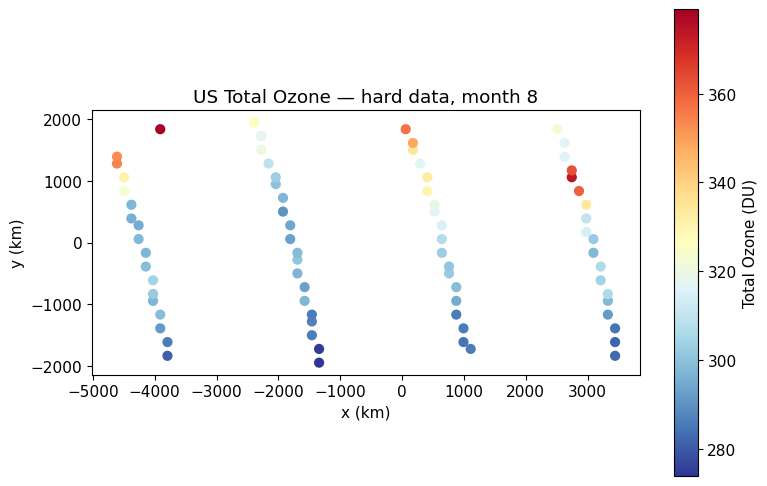

In [4]:
# ── Use a single time step (month 8 = August) for spatial analysis ─────────
T = 8
h = hard[hard.Time == T].copy()
ch_h = h[['x', 'y']].values          # (nh, 2)
zh   = h['Value'].values.astype(float)

# Also build full space-time arrays for later BME
from stamps.general.valstvgx import valstv2stg
all_coords = hard[['x', 'y', 'Time']].values.astype(float)
all_vals   = hard['Value'].values.astype(float)
grid_z, grid_s, grid_t, _ = valstv2stg(all_coords, all_vals)

print(f'Month {T}: {len(zh)} hard data points')

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(ch_h[:, 0], ch_h[:, 1], c=zh, cmap='RdYlBu_r', s=40, zorder=3)
plt.colorbar(sc, ax=ax, label='Total Ozone (DU)')
ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.set_title(f'US Total Ozone — hard data, month {T}')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 2  Visual Screening — Covariance Map and Polar Covariance Plot

**Tier 1 of the isotropy workflow.**  
The 2-D covariance map plots $\hat{C}(h_x, h_y)$ as a colour field over the displacement vector grid.  
For an isotropic field, iso-covariance contours are circles.  
Elongated (elliptical) contours signal geometric anisotropy.

*Reference: Cressie (1993, §2.4)*

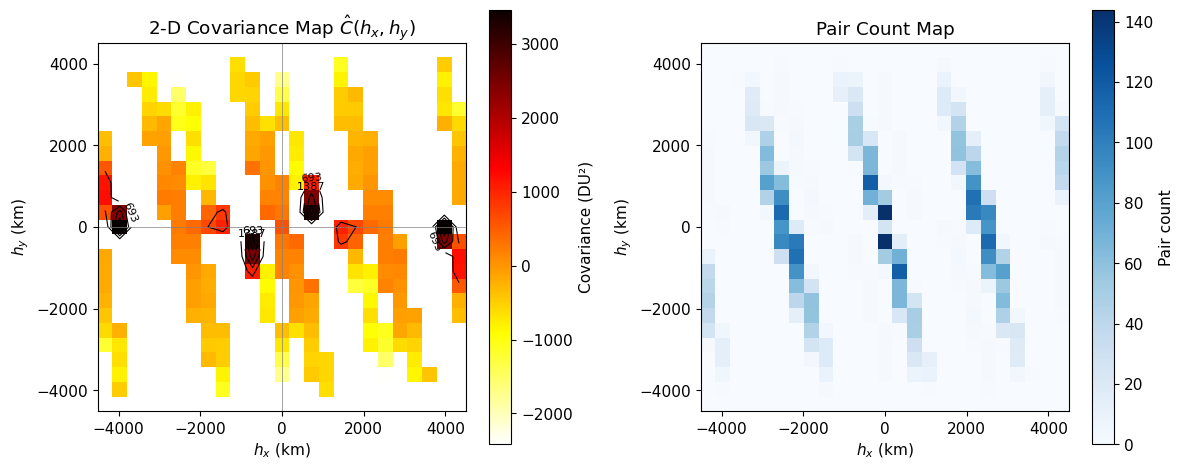

Estimated sill: 3466.4 DU²


In [5]:
# ── 2-D covariance map ─────────────────────────────────────────────────────
from stamps.general.coord2dist import coord2dist

max_dist = coord2dist(ch_h, ch_h).max()
dx_range = dy_range = max_dist * 0.5   # half the domain extent
n_bins = 25

# Remove trend (mean) before computing covariance
zh_res = zh - zh.mean()

C_map, N_map, hx, hy = covariancemap(
    ch_h, zh_res, dx_range, dy_range, n_bins, tol_frac=1.2
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
im = ax.pcolormesh(hx, hy, C_map, cmap='hot_r', shading='auto')
plt.colorbar(im, ax=ax, label='Covariance (DU²)')
# overlay contours at specific covariance levels
sill_est = float(np.nanmax(C_map))
levels = np.sort(sill_est * np.array([0.2, 0.4, 0.6, 0.8]))
c_cont = ax.contour(hx, hy, np.nan_to_num(C_map, nan=0),
                    levels=levels, colors='k', linewidths=0.8)
ax.clabel(c_cont, fmt='%.0f', fontsize=8)
ax.set_xlabel('$h_x$ (km)')
ax.set_ylabel('$h_y$ (km)')
ax.set_title('2-D Covariance Map $\\hat{C}(h_x, h_y)$')
ax.set_aspect('equal')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)

ax = axes[1]
im2 = ax.pcolormesh(hx, hy, N_map, cmap='Blues', shading='auto')
plt.colorbar(im2, ax=ax, label='Pair count')
ax.set_xlabel('$h_x$ (km)')
ax.set_ylabel('$h_y$ (km)')
ax.set_title('Pair Count Map')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()
print(f'Estimated sill: {sill_est:.1f} DU²')

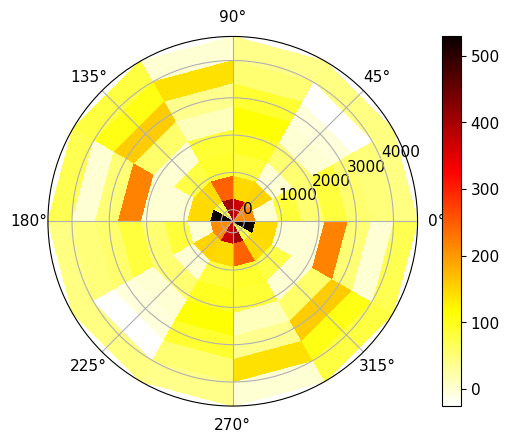

In [6]:
# ── Polar directional covariance plot ──────────────────────────────────────
# Evaluate at 6 directions in [-pi/2, pi/2)
rLag    = np.linspace(0, max_dist * 0.5, 8)
rLagTol = np.ones_like(rLag) * (rLag[1] - rLag[0]) / 2.0
angLag  = np.arange(-np.pi/2, np.pi/2, 30/180.*np.pi)   # 6 directions
angTol  = np.ones_like(angLag) * 15/180.*np.pi

tME = np.array([0.])   # single time step
grid_v_aug = zh_res.reshape(-1, 1)

CC, CCn, lagr, lagt, angLag = polarstcovmap(
    ch_h, tME, grid_v_aug,
    rLag, rLagTol,
    angLag=angLag, angTol=angTol,
    plot=True
)

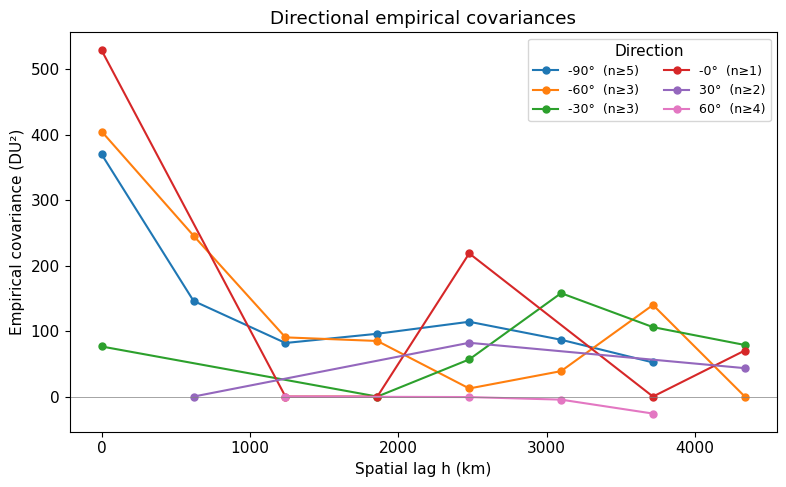

In [7]:
# ── Directional covariance curves ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.tab10(np.linspace(0, 0.6, len(angLag)))
for i, ang in enumerate(angLag):
    c_dir = CC[i][:, 0]
    n_dir = CCn[i][:, 0]
    mask = ~np.isnan(c_dir) & (n_dir > 0)
    ax.plot(lagr[mask, 0], c_dir[mask],
            '-o', color=colors[i], ms=5,
            label=f'{np.degrees(ang):.0f}°  (n≥{int(n_dir[mask].min()) if mask.sum()>0 else 0})')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('Spatial lag h (km)')
ax.set_ylabel('Empirical covariance (DU²)')
ax.set_title('Directional empirical covariances')
ax.legend(title='Direction', fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

## 3  Effect Size — Anisotropy Parameter Estimation

**Tier 2 of the isotropy workflow.**  
Extract the effective range at each direction and fit the anisotropy ellipse:

$$a(\phi) = \frac{a_{max} \cdot r}{\sqrt{r^2\cos^2(\phi-\theta) + \sin^2(\phi-\theta)}}$$

The ratio $\hat{r} = a_{min}/a_{max} \in (0,1]$.  
* $\hat{r} \geq 0.85$ → anisotropy negligible → use isotropic model  
* $0.65 \leq \hat{r} < 0.85$ → moderate anisotropy → run formal test  
* $\hat{r} < 0.65$ → strong anisotropy → use anisotropic model

*References: Zimmerman (1993); Goovaerts (1997 §4.3)*

In [8]:
theta_hat, r_hat, a_max_hat, a_dirs, valid = estimate_anisotropy_params(
    CC, CCn, angLag, lagr
)

print(f'Estimated principal-axis angle : θ̂ = {np.degrees(theta_hat):.1f}°')
print(f'Estimated anisotropy ratio     : r̂ = {r_hat:.3f}')
print(f'Estimated principal range      : â_max = {a_max_hat:.1f} km')
print(f'Estimated secondary range      : â_min = {a_max_hat * r_hat:.1f} km')
print()
if r_hat >= 0.85:
    print('→ Effect size: WEAK (r̂ ≥ 0.85).  Proceed with isotropic model.')
elif r_hat >= 0.65:
    print('→ Effect size: MODERATE (0.65 ≤ r̂ < 0.85).  Run formal isotropy test.')
else:
    print('→ Effect size: STRONG (r̂ < 0.65).  Anisotropic model warranted.')

Estimated principal-axis angle : θ̂ = 57.0°
Estimated anisotropy ratio     : r̂ = 0.317
Estimated principal range      : â_max = 1206.4 km
Estimated secondary range      : â_min = 383.0 km

→ Effect size: STRONG (r̂ < 0.65).  Anisotropic model warranted.


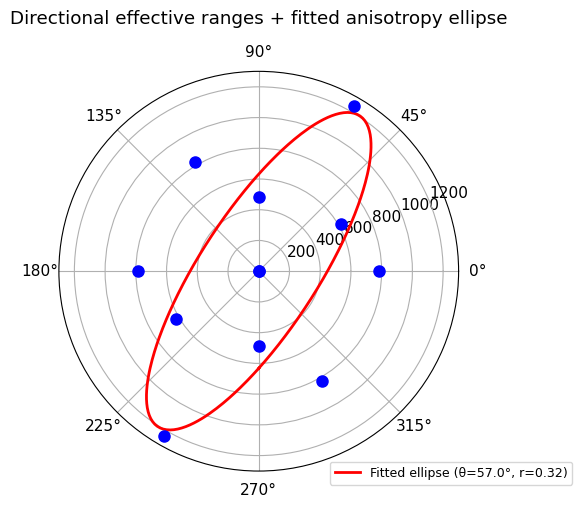

In [9]:
# ── Visualise directional ranges and fitted ellipse ────────────────────────
def ellipse_range(phi, theta, r, a_max):
    denom = np.sqrt(r**2 * np.cos(phi - theta)**2 + np.sin(phi - theta)**2)
    return a_max * r / denom

phi_plot = np.linspace(-np.pi/2, np.pi/2, 180)
a_fit    = ellipse_range(phi_plot, theta_hat, r_hat, a_max_hat)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))

# Empirical ranges (both halves of the rose)
for ang, a_d, v in zip(angLag, a_dirs, valid):
    if v:
        ax.plot([ang, ang + np.pi], [a_d, a_d], 'bo', ms=8, zorder=4)

# Fitted ellipse
ax.plot(np.concatenate([phi_plot, phi_plot + np.pi]),
        np.concatenate([a_fit, a_fit]),
        'r-', lw=2, label=f'Fitted ellipse (θ={np.degrees(theta_hat):.1f}°, r={r_hat:.2f})')

ax.set_title('Directional effective ranges + fitted anisotropy ellipse', pad=15)
ax.legend(loc='lower right', fontsize=9, bbox_to_anchor=(1.3, -0.05))
plt.tight_layout()
plt.show()

## 4  Formal Isotropy Test — Spatial Rotation Bootstrap

**Tier 3 of the isotropy workflow.**  
The bootstrap test statistic is the maximum directional covariance contrast between the two principal directions:

$$T_n = \max_{l} |\hat{C}(h_l, \hat{\theta}) - \hat{C}(h_l, \hat{\theta}+90°)|$$

The null distribution is obtained by rotating all coordinates by $B=499$ random angles.

*Reference: Guan, Sherman & Calvin (2004); Davison & Hinkley (1997, Ch. 2)*

In [10]:
result = isotropy_test(
    ch_h, zh_res, rLag, rLagTol, angLag, angTol,
    method='bootstrap',
    n_boot=199,   # use 499+ for publication-quality results
    alpha=0.05,
    seed=42,
)

print('=== Isotropy Test Results ===')
print(f"Test statistic  T_n = {result['test_stat']:.4f}")
print(f"Bootstrap p-value   = {result['p_value']:.3f}")
print(f"Reject H₀ (isotropy): {result['reject_H0']}")
print(f"Effect size: r̂ = {result['r_hat']:.3f}")
print()
print('Interpretation:', result['message'])

=== Isotropy Test Results ===
Test statistic  T_n = 162.7850
Bootstrap p-value   = 0.603
Reject H₀ (isotropy): False
Effect size: r̂ = 0.317

Interpretation: Effect size: r̂ = 0.317 < 0.65 — strong anisotropy.  Principal axis: θ̂ = 57.0°.  p-value = 0.603.  H₀ (isotropy) not rejected at α = 0.05.


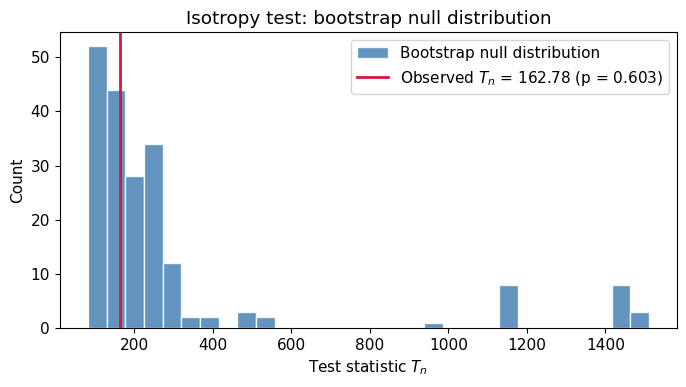

In [11]:
# ── Bootstrap null distribution ────────────────────────────────────────────
T_boot = result.get('T_boot', np.array([]))
if T_boot.size > 0:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(T_boot, bins=30, color='steelblue', edgecolor='white', alpha=0.85,
            label='Bootstrap null distribution')
    ax.axvline(result['test_stat'], color='crimson', lw=2,
               label=f"Observed $T_n$ = {result['test_stat']:.2f} (p = {result['p_value']:.3f})")
    ax.set_xlabel('Test statistic $T_n$')
    ax.set_ylabel('Count')
    ax.set_title('Isotropy test: bootstrap null distribution')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 5  Anisotropic Covariance Model Fitting

Fit a theoretical covariance model to the directional empirical covariances using  
**weighted least squares (WLS)** with the principal-axis angle $\theta$ and ratio $r$ as free parameters.

The anisotropic range at direction $\phi$ is:

$$a(\phi) = \frac{a_0 \cdot r}{\sqrt{r^2\cos^2(\phi-\theta) + \sin^2(\phi-\theta)}}$$

*References: Goovaerts (1997 §4.3); Cressie (1985)*

In [12]:
# ── Prepare inputs for covmodelfit ─────────────────────────────────────────
# Omnidirectional covariance for initial isotropic fit
C_omni, Cn_omni, lagr_s, lagt_s = stcov(
    ch_h, tME, grid_v_aug, rLag, rLagTol)

# Covariance model: exponential + nugget  (flat list of model name strings)
covmodel = ['exponentialC', 'nuggetC']
# Initial parameters: (sill, range) for exponential; (nugget,) for nuggetC
sill0   = float(np.nanmax(C_omni[:, 0])) * 0.9
nugget0 = float(np.nanmax(C_omni[:, 0])) * 0.1
range0  = float(a_max_hat)
covparam0 = [(sill0, range0), (nugget0,)]

# ── Isotropic fit ─────────────────────────────────────────────────────────
covparam_iso, opt_iso = covmodelfit(
    lagr_s, lagt_s, C_omni, Cn_omni, covmodel, covparam0
)
print('Isotropic fit:', covparam_iso)
print(f'WLS objective = {opt_iso:.4f}')

starpy Warning: roundoff limited found. Set relative value to 10**-8
Isotropic fit: [[np.float64(482.9300291306227), array([2738.36030249])], [np.float64(13.818289601554907)]]
WLS objective = 11576.3995


In [13]:
# ── Anisotropic fit ───────────────────────────────────────────────────────
# lag_cov_v as list of (nls, 1) arrays for each direction
CC_spatial = [c[:, 0:1] for c in CC]   # keep only t=0 column
CCn_spatial = [c[:, 0:1] for c in CCn]

try:
    result_aniso = covmodelfit(
        lagr_s, lagt_s,
        CC_spatial, CCn_spatial,
        covmodel, covparam0,
        theta0=theta_hat, ratio0=max(r_hat, 0.3),
        lag_th=angLag,
    )
    covparam_aniso, theta_opt, ratio_opt, opt_aniso = result_aniso
    print('Anisotropic fit:', covparam_aniso)
    print(f'Principal axis  θ = {np.degrees(theta_opt):.1f}°')
    print(f'Anisotropy ratio r = {ratio_opt:.3f}')
    print(f'WLS objective = {opt_aniso:.4f}')
except Exception as e:
    print('Anisotropic fit error:', e)
    # Fall back to initial estimates
    covparam_aniso = covparam_iso
    theta_opt, ratio_opt = theta_hat, r_hat

starpy Warning: roundoff limited found. Set relative value to 10**-8
Anisotropic fit: [[np.float64(313.4363112571738), array([6031.75719537])], [np.float64(92.12193067703272)]]
Principal axis  θ = 102.0°
Anisotropy ratio r = 0.635
WLS objective = 48268.5842


/var/folders/lm/y022zy7147q8x2k1bjrct88w0000gn/T/ipykernel_74379/3094118055.py:2: DeprecationWarning: Importing from 'stamps.stats.dependence.stcovfit' is deprecated. Use 'stamps.stats.dependence.covariance.stcovfit' instead.
  from stamps.stats.dependence.stcovfit import anisocovmodelest, covmodelest


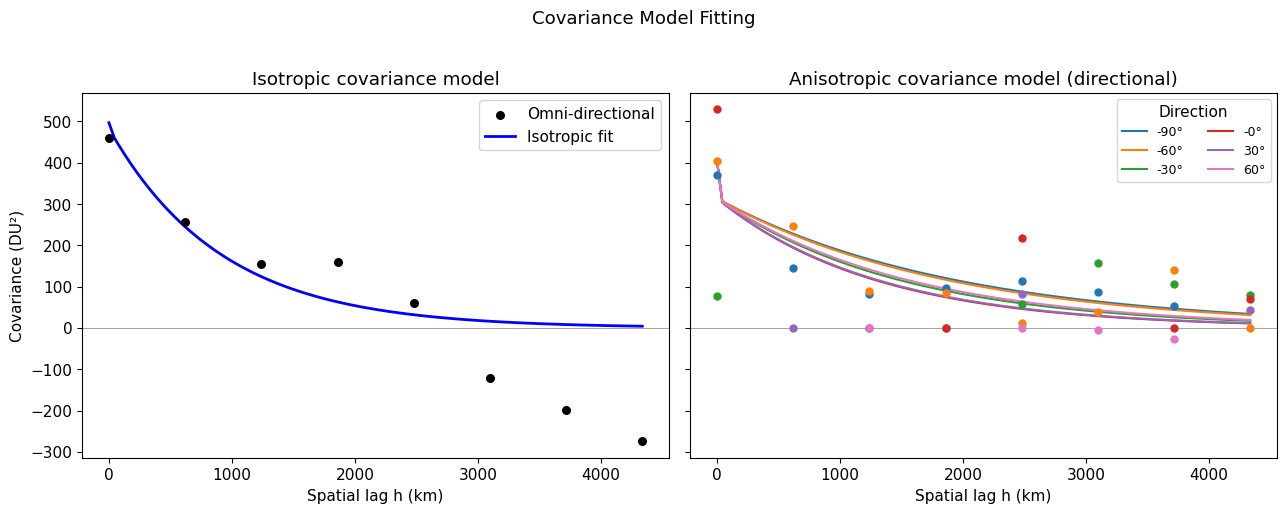

In [14]:
# ── Plot isotropic vs anisotropic model fits ──────────────────────────────
from stamps.stats.dependence.stcovfit import anisocovmodelest, covmodelest

h_plot = np.linspace(0, rLag.max(), 100)
h_plot_2d = h_plot.reshape(-1, 1)
t_zero_2d = np.zeros((100, 1))

# Isotropic model curve
C_iso_fit, _ = covmodelest(h_plot_2d, t_zero_2d, covmodel, covparam_iso)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Left: isotropic fit
ax = axes[0]
C_omni_1d = C_omni[:, 0]
mask = ~np.isnan(C_omni_1d)
ax.scatter(lagr_s[mask, 0], C_omni_1d[mask], c='k', s=30, zorder=4,
           label='Omni-directional')
ax.plot(h_plot, C_iso_fit[:, 0], 'b-', lw=2, label='Isotropic fit')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('Spatial lag h (km)')
ax.set_ylabel('Covariance (DU²)')
ax.set_title('Isotropic covariance model')
ax.legend()

# Right: anisotropic fit at multiple directions
ax = axes[1]
colors = plt.cm.tab10(np.linspace(0, 0.6, len(angLag)))
try:
    C_aniso_curves, _ = anisocovmodelest(
        covmodel, covparam_aniso, theta_opt, ratio_opt,
        angLag, h_plot_2d, t_zero_2d)
    for i, ang in enumerate(angLag):
        c_dir = CC[i][:, 0]
        n_dir = CCn[i][:, 0]
        ok = ~np.isnan(c_dir) & (n_dir > 0)
        ax.scatter(lagr_s[ok, 0], c_dir[ok], color=colors[i], s=25, zorder=4)
        ax.plot(h_plot, C_aniso_curves[i][:, 0],
                color=colors[i], lw=1.5,
                label=f'{np.degrees(ang):.0f}°')
except Exception as e:
    ax.text(0.5, 0.5, f'Error: {e}', transform=ax.transAxes, ha='center')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('Spatial lag h (km)')
ax.set_title('Anisotropic covariance model (directional)')
ax.legend(title='Direction', ncol=2, fontsize=9)

plt.suptitle('Covariance Model Fitting', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6  Anisotropic Kriging / BME Estimation

The anisotropic covariance enters BME / kriging through the `coord2K` function, which now accepts
`aniso_angle` (degrees) and `aniso_ratio` parameters.  Internally it applies `aniso2iso` to the
spatial coordinates before computing Euclidean distances, so any covariance model defined in the
isotropic space is automatically evaluated at anisotropic distances.

*Reference: Journel & Huijbregts (1978 §I.4)*

In [15]:
# ── Build estimation grid over the domain ─────────────────────────────────
x_grid = np.linspace(hard.x.min(), hard.x.max(), 40)
y_grid = np.linspace(hard.y.min(), hard.y.max(), 25)
XX, YY = np.meshgrid(x_grid, y_grid)
ck = np.column_stack([XX.ravel(), YY.ravel()])  # (nk, 2)

print(f'Estimation grid: {ck.shape[0]} points')

Estimation grid: 1000 points


In [16]:
# ── Simple ordinary kriging with anisotropic covariance ───────────────────
from stamps.estimation.kriging import kriging

# Use August data
zh_mean = zh.mean()

# Anisotropic kriging: pass aniso params
theta_deg = float(np.degrees(theta_opt))   # convert to degrees for coord2K

# kriging(ck, ch, zh, model, param, nhmax, dmax, order, options,
#          aniso_angle, aniso_ratio)
nhmax = 20
dmax  = max_dist * 0.6

zk_aniso, sk_aniso = kriging(
    ck, ch_h, zh - zh_mean,
    covmodel, covparam_aniso,
    nhmax, dmax,
    aniso_angle=theta_deg,
    aniso_ratio=float(ratio_opt),
)
zk_aniso = zk_aniso.ravel() + zh_mean
sk_aniso = sk_aniso.ravel()

# Isotropic kriging for comparison
zk_iso, sk_iso = kriging(
    ck, ch_h, zh - zh_mean,
    covmodel, covparam_iso,
    nhmax, dmax,
)
zk_iso = zk_iso.ravel() + zh_mean
sk_iso = sk_iso.ravel()

print('Anisotropic kriging done.')
print(f'  Estimate range: {zk_aniso[~np.isnan(zk_aniso)].min():.1f} – {zk_aniso[~np.isnan(zk_aniso)].max():.1f} DU')

Anisotropic kriging done.
  Estimate range: 279.8 – 349.2 DU


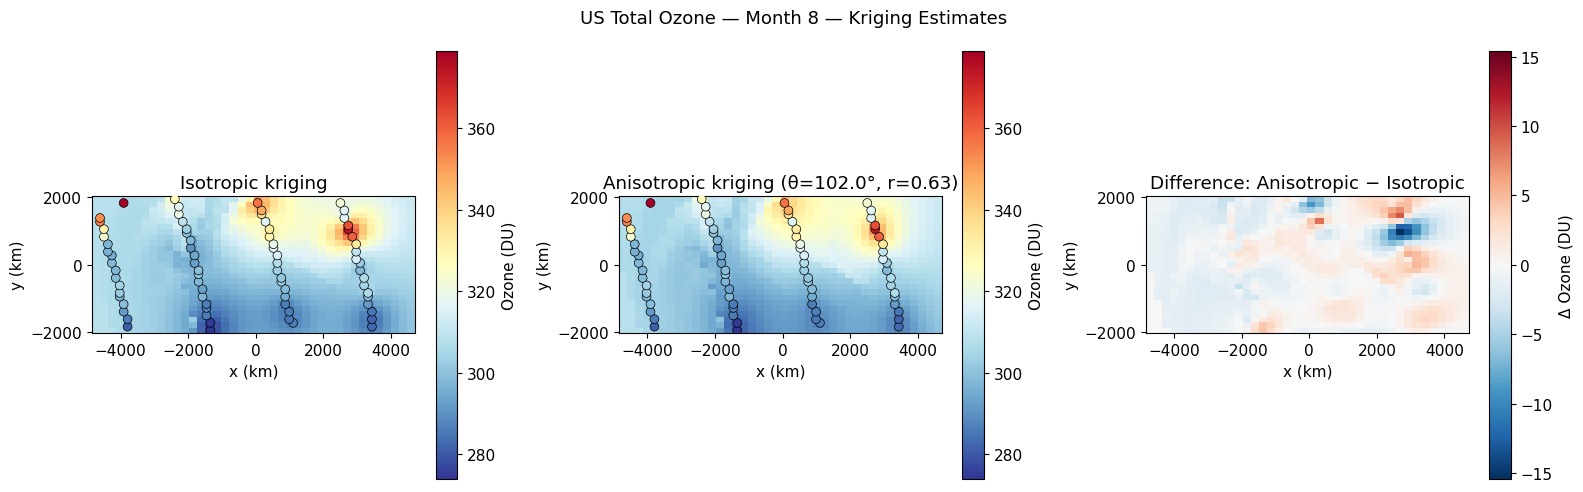

In [17]:
# ── Comparison plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
vmin, vmax = zh.min(), zh.max()

for ax, zk, title in zip(
    axes[:2],
    [zk_iso, zk_aniso],
    ['Isotropic kriging', f'Anisotropic kriging (θ={theta_deg:.1f}°, r={ratio_opt:.2f})'],
):
    im = ax.pcolormesh(XX, YY, zk.reshape(XX.shape),
                       cmap='RdYlBu_r', vmin=vmin, vmax=vmax, shading='auto')
    ax.scatter(ch_h[:, 0], ch_h[:, 1], c=zh, cmap='RdYlBu_r',
               vmin=vmin, vmax=vmax, edgecolors='k', linewidths=0.5, s=40, zorder=3)
    plt.colorbar(im, ax=ax, label='Ozone (DU)')
    ax.set_xlabel('x (km)'); ax.set_ylabel('y (km)')
    ax.set_title(title)
    ax.set_aspect('equal')

# Difference plot
ax = axes[2]
diff = zk_aniso - zk_iso
lim = max(abs(diff.min()), abs(diff.max()))
im3 = ax.pcolormesh(XX, YY, diff.reshape(XX.shape),
                    cmap='RdBu_r', vmin=-lim, vmax=lim, shading='auto')
plt.colorbar(im3, ax=ax, label='Δ Ozone (DU)')
ax.set_xlabel('x (km)'); ax.set_ylabel('y (km)')
ax.set_title('Difference: Anisotropic − Isotropic')
ax.set_aspect('equal')

plt.suptitle(f'US Total Ozone — Month {T} — Kriging Estimates', fontsize=13)
plt.tight_layout()
plt.show()

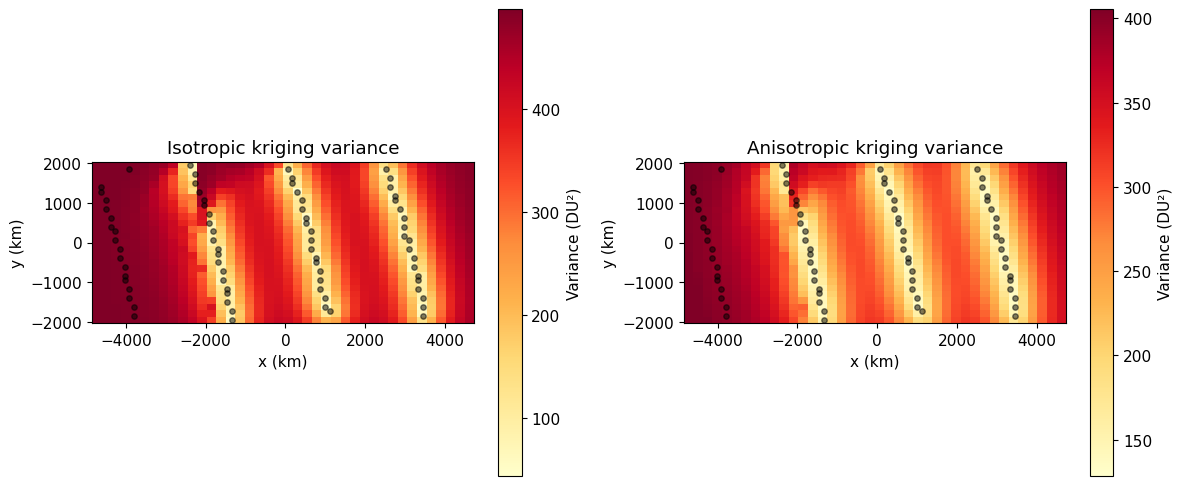

Mean kriging variance  — isotropic:   350.57 DU²
Mean kriging variance  — anisotropic: 285.70 DU²


In [18]:
# ── Kriging variance comparison ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, sk, title in zip(
    axes,
    [sk_iso, sk_aniso],
    ['Isotropic kriging variance', 'Anisotropic kriging variance'],
):
    im = ax.pcolormesh(XX, YY, sk.reshape(XX.shape),
                       cmap='YlOrRd', shading='auto')
    plt.colorbar(im, ax=ax, label='Variance (DU²)')
    ax.scatter(ch_h[:, 0], ch_h[:, 1], c='k', s=15, zorder=3, alpha=0.5)
    ax.set_xlabel('x (km)'); ax.set_ylabel('y (km)')
    ax.set_title(title)
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print(f'Mean kriging variance  — isotropic:   {sk_iso.mean():.2f} DU²')
print(f'Mean kriging variance  — anisotropic: {sk_aniso.mean():.2f} DU²')

## 7  Summary and Decision Checklist

The following checklist summarises the tiered isotropy workflow applied above.
Each tier provides evidence about whether to adopt the anisotropic model.

In [19]:
print('╔══════════════════════════════════════════════════════════════╗')
print('║         ANISOTROPY ANALYSIS SUMMARY — US Total Ozone        ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Tier 1 (Visual)   Covariance map contours ... INSPECT      ║')
tier2_flag = '✓ isotropic OK' if r_hat >= 0.85 else ('△ moderate' if r_hat >= 0.65 else '✗ anisotropic')
print(f'║  Tier 2 (Effect)   r̂ = {r_hat:.3f}  θ̂ = {np.degrees(theta_hat):.1f}°  → {tier2_flag:<15} ║')
pv_str = f"{result['p_value']:.3f}" if not np.isnan(result['p_value']) else 'N/A'
tier3_flag = 'H₀ rejected' if result['reject_H0'] else 'H₀ not rejected'
print(f'║  Tier 3 (Bootstrap) p = {pv_str}   → {tier3_flag:<22} ║')
n_obs = len(zh)
size_ok = n_obs >= 100
print(f'║  Tier 4 (Practical) n = {n_obs}   n≥100: {"✓" if size_ok else "✗"}                     ║')
print('╠══════════════════════════════════════════════════════════════╣')
decision = 'USE ANISOTROPIC MODEL' if (r_hat < 0.85 and result['reject_H0'] and size_ok) else 'ISOTROPIC MODEL ADEQUATE'
print(f'║  Decision: {decision:<50} ║')
print('╚══════════════════════════════════════════════════════════════╝')
print()
print('Fitted anisotropic model parameters:')
print(f'  Principal-axis angle : {np.degrees(theta_opt):.1f}°')
print(f'  Anisotropy ratio     : {ratio_opt:.3f}')
print(f'  Covariance model     : {covmodel}')
print(f'  Parameters (aniso.)  : {covparam_aniso}')

╔══════════════════════════════════════════════════════════════╗
║         ANISOTROPY ANALYSIS SUMMARY — US Total Ozone        ║
╠══════════════════════════════════════════════════════════════╣
║  Tier 1 (Visual)   Covariance map contours ... INSPECT      ║
║  Tier 2 (Effect)   r̂ = 0.317  θ̂ = 57.0°  → ✗ anisotropic   ║
║  Tier 3 (Bootstrap) p = 0.603   → H₀ not rejected        ║
║  Tier 4 (Practical) n = 76   n≥100: ✗                     ║
╠══════════════════════════════════════════════════════════════╣
║  Decision: ISOTROPIC MODEL ADEQUATE                           ║
╚══════════════════════════════════════════════════════════════╝

Fitted anisotropic model parameters:
  Principal-axis angle : 102.0°
  Anisotropy ratio     : 0.635
  Covariance model     : ['exponentialC', 'nuggetC']
  Parameters (aniso.)  : [[np.float64(313.4363112571738), array([6031.75719537])], [np.float64(92.12193067703272)]]


## References

1. **Guan, Y., Sherman, M., & Calvin, J.A. (2004).** A nonparametric test for spatial isotropy using subsampling. *JASA*, 99(467), 810–821.
2. **Goovaerts, P. (1997).** *Geostatistics for Natural Resources Evaluation.* Oxford University Press. Section 4.3.
3. **Cressie, N.A.C. (1993).** *Statistics for Spatial Data* (rev. ed.). Wiley. Sections 2.4, 2.6.
4. **Journel, A.G. & Huijbregts, C.J. (1978).** *Mining Geostatistics.* Academic Press. Section I.4.
5. **Zimmerman, D.L. (1993).** Another look at anisotropy in geostatistics. *Mathematical Geology*, 25(4), 453–470.
6. **Davison, A.C. & Hinkley, D.V. (1997).** *Bootstrap Methods and Their Application.* Cambridge. Chapter 2.
7. **Self, S.G. & Liang, K.-Y. (1987).** Asymptotic properties of MLE and LRT under non-standard conditions. *JASA*, 82(398), 605–610.
8. **Christakos, G. & Vyas, V.M. (1998).** A novel method for studying population exposure to outdoor air pollutants. *Environment International*, 24(1–2), 141–158.